In [2]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers import Nagai2007

In [3]:
importlib.reload(Nagai2007)

Nagai2007.TableA1().df

,Runs,Sample,P0,c500,alpha,beta,gamma
0,Chandra Obs.,Relaxed,3.3,1.8,1.3,4.3,0.7
1,Cooling+SF,Relaxed,3.3,1.8,1.3,4.3,1.1
2,Cooling+SF,Unrelaxed,2.0,1.5,1.4,4.3,1.0
3,Non-radiative,Relaxed,38.0,3.0,1.1,4.3,0.3
4,Non-radiative,Unrelaxed,3.0,1.5,1.4,4.3,0.9


In [ ]:
importlib.reload(Nagai2007)
fig, ax = Nagai2007.FigA1().full()

from Models import HaloModels
importlib.reload(HaloModels)

hmod = HaloModels.pyccl_model(Nagai2007.HaloProfile().info)
rs, z, logM500c = np.geomspace(1e-2, 1e1, 25), 3, np.log10(9e13)
x = rs*u.Mpc/hmod.rdel('500c')(z, logM500c)
P_del = lambda N07: (N07.Pressure(rs, z, logM500c)()/N07.P500(z, logM500c))[:, 0, 0]
N07 = lambda **spefs: Nagai2007.HaloProfile(**spefs, H=hmod.H, rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))

ax.scatter(x, P_del(N07(Run='Obs', Sample='Rel')), s=100, marker='X', alpha=0.8, c='purple', label='Obs')
ax.scatter(x, P_del(N07(Run='CSF', Sample='Rel')), s=100, marker='X', alpha=0.8, c='cyan', label='cool+SF')
ax.scatter(x, P_del(N07(Run='NR', Sample='Rel')), s=100, marker='X', alpha=0.8, c='orange', label='non-rad')

ax.legend(); plt.show()

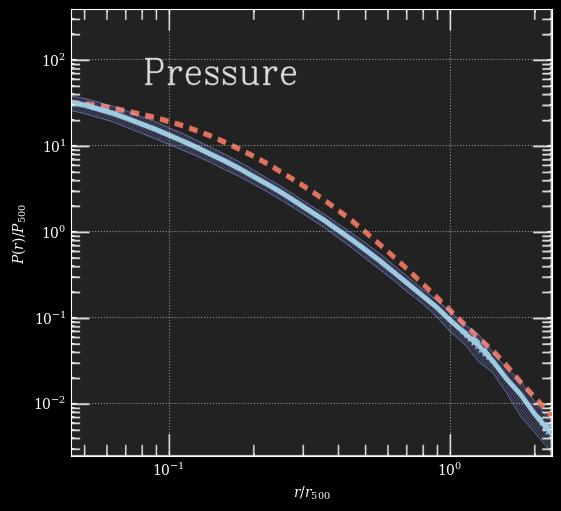

In [2]:
importlib.reload(Nagai2007)

fig, axs = Nagai2007.Fig1d().full()

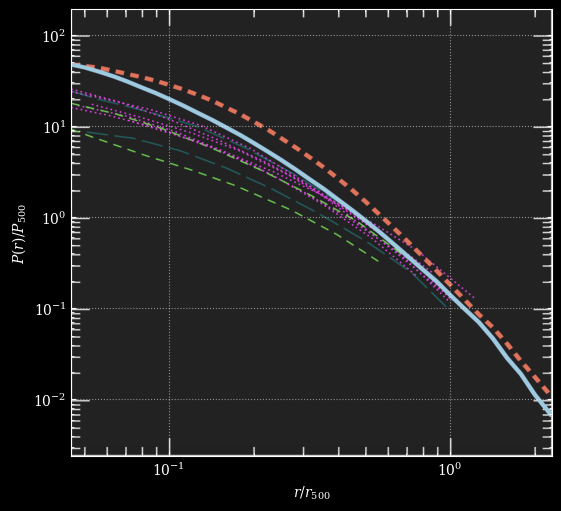

In [3]:
importlib.reload(Nagai2007)

fig, axs = Nagai2007.Fig2d().full()